In [1]:
import pandas as pd
df=pd.read_excel("sample-chocolate-shipments-data-all-Apr-2025.xlsx")

In [2]:
print("first 5 rows")
print(df.head())

first 5 rows
  ShipmentID  SPID  PID GID   Shipdate   Amount  Boxes Order_Status
0  S00000004  SP01  P14  G2 2023-05-05  7107.75    285    Delivered
1  S00000009  SP01  P14  G4 2023-08-22  8664.75    377    Cancelled
2  S00000013  SP01  P14  G6 2023-10-23  2346.75    103    Delivered
3  S00000032  SP01  P14  G2 2023-06-06  4234.50    152    Delivered
4  S00000033  SP01  P14  G2 2024-12-03  9252.00    421    Delivered


In [3]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25076 entries, 0 to 25075
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ShipmentID    25076 non-null  object        
 1   SPID          25076 non-null  object        
 2   PID           25076 non-null  object        
 3   GID           25076 non-null  object        
 4   Shipdate      25076 non-null  datetime64[ns]
 5   Amount        25076 non-null  float64       
 6   Boxes         25076 non-null  int64         
 7   Order_Status  25076 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 1.5+ MB
None


In [4]:
print("\nStatistical Summary:")
print(df.describe(include='all'))


Statistical Summary:
       ShipmentID   SPID    PID    GID                       Shipdate  \
count       25076  25076  25076  25076                          25076   
unique      25076     25     22      6                            NaN   
top     S00165311   SP22    P16     G1                            NaN   
freq            1   2036   1859   7127                            NaN   
mean          NaN    NaN    NaN    NaN  2024-02-27 16:50:06.795342336   
min           NaN    NaN    NaN    NaN            2023-01-02 00:00:00   
25%           NaN    NaN    NaN    NaN            2023-08-22 00:00:00   
50%           NaN    NaN    NaN    NaN            2024-02-06 00:00:00   
75%           NaN    NaN    NaN    NaN            2024-10-08 00:00:00   
max           NaN    NaN    NaN    NaN            2025-03-31 00:00:00   
std           NaN    NaN    NaN    NaN                            NaN   

              Amount         Boxes Order_Status  
count   25076.000000  25076.000000        25076  
u

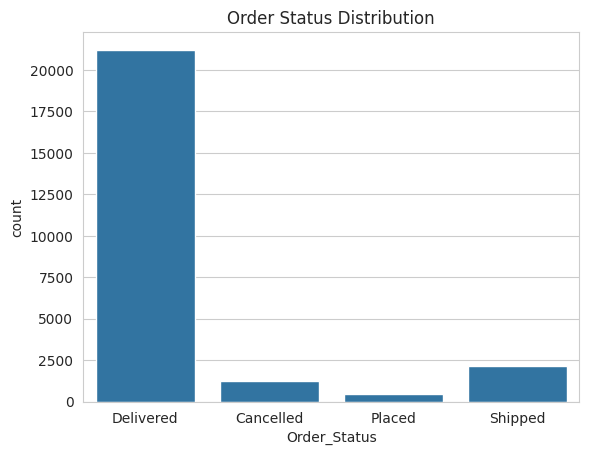

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Order_Status', data=df)
plt.title('Order Status Distribution')
plt.show()

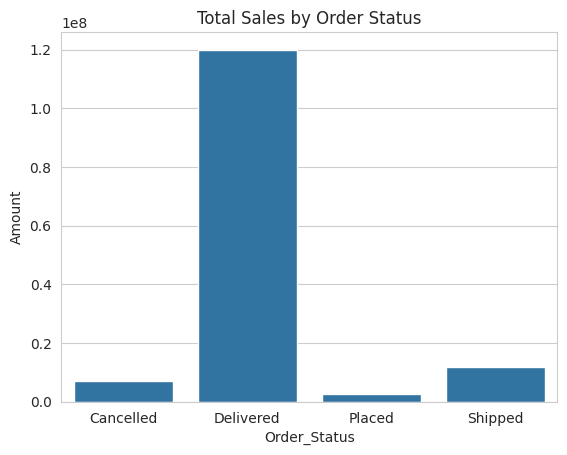

In [8]:
sales_by_status = df.groupby('Order_Status')['Amount'].sum().reset_index()

sns.barplot(x='Order_Status', y='Amount', data=sales_by_status)
plt.title('Total Sales by Order Status')
plt.show()

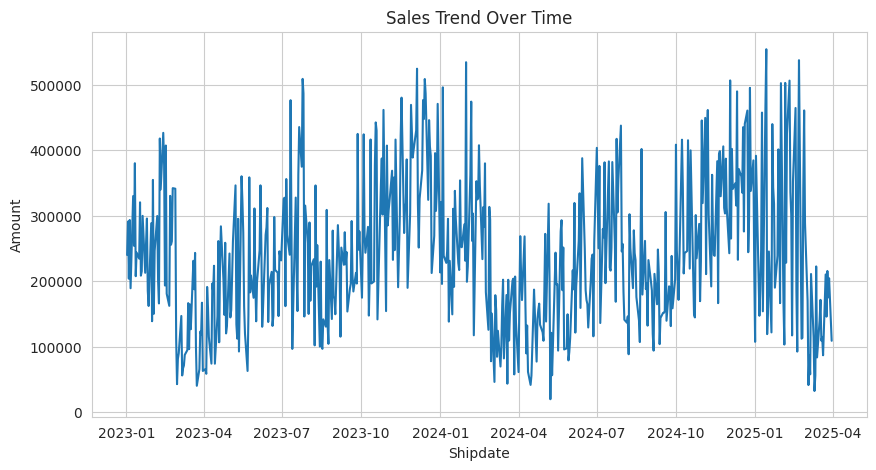

In [9]:
df['Shipdate'] = pd.to_datetime(df['Shipdate'])

daily_sales = df.groupby('Shipdate')['Amount'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Shipdate', y='Amount', data=daily_sales)
plt.title('Sales Trend Over Time')
plt.show()

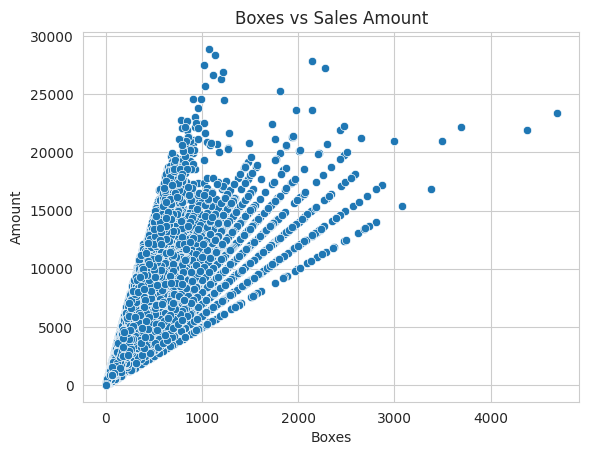

In [10]:
sns.scatterplot(x='Boxes', y='Amount', data=df)
plt.title('Boxes vs Sales Amount')
plt.show()

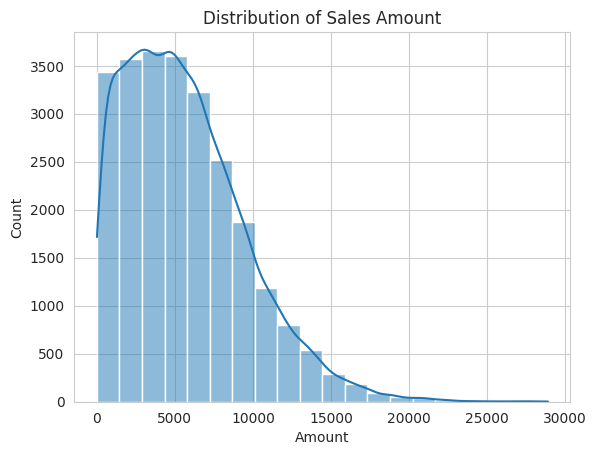

In [11]:
sns.histplot(df['Amount'], bins=20, kde=True)
plt.title('Distribution of Sales Amount')
plt.show()